# **02 - Exploratory Analysis**

**Summary - Respiratory Admissions & Inequalities**

This notebook explores variation in respiratory hospital admissions using cleaned, spell-level data from the synthetic HES extract (`apc_clean.parquet`).  
Four inferential comparisons were performed to assess potential differences in patient or admission characteristics across clinical and deprivation groupings.

**Statistical Tests**

| # | Hypothesis | Test | Test Statistic | p-value | Interpretation |
|---|-------------|------|----------------|----------|----------------|
| 1 | **Length of stay (LOS) differs by respiratory group** | Kruskal–Wallis | H = 43.6 | p < 0.001 | Significant difference: LOS is longer for COPD and pneumonia, shorter for asthma and other respiratory conditions. |
| 2 | **Age differs by respiratory group** | Kruskal–Wallis | H = 3.6 | p = 0.309 | Not significant — age distribution is broadly similar across diagnostic groups, consistent with synthetic dataset structure. |
| 3 | **Emergency admission rate differs by diagnosis** | Chi-squared | χ² = 3.47 | p = 0.325 | Not significant — emergency versus planned admission proportions are comparable across respiratory categories. |
| 4 | **Admissions per patient differ by deprivation quintile (IMD)** | Kruskal–Wallis | H = 20.8 | p < 0.001 | Statistically significant but small effect — slightly higher repeat admissions in deprived quintiles, though the effect size is minimal. |


**Findings**

- **Length of Stay (LOS)** shows the clearest clinical signal. Chronic and acute lower-respiratory diagnoses (COPD and pneumonia) are associated with longer hospital stays compared to asthma and other conditions.  
  This is consistent with real-world patterns and validates the data processing workflow.

- **Age distribution** and **emergency admission proportions** show no meaningful variation by diagnosis.  
  This likely reflects the synthetic design, where age and admission method are not tightly linked to condition codes.

- **Repeat admissions** are rare overall (mean 1.13 per patient), producing a statistically detectable but practically small difference by deprivation quintile.  
  Further investigation of readmissions will be conducted at the patient level in Week 4.

**Interpretation**

Overall, the EDA highlights clinically plausible variation in length of stay by respiratory group but limited evidence of strong inequality effects at the spell level.  
Deprivation and readmission patterns will be revisited in the patient-level analysis phase, where cumulative hospital use can be examined more robustly.

**Note on time coverage:**  
This dataset spans 2018–2021 and includes the COVID-19 period, which disrupted admission patterns nationally.  
Sharp dips in early 2020 and rebounds in 2021 reflect pandemic-related service changes rather than true respiratory demand.  
Model outputs going forwards should therefore be interpreted with caution for general use.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency

# Load cleaned data
df = pd.read_parquet("../data/processed/apc_clean.parquet")
print(df.shape)
df.head()

(145305, 16)


,patient_id,adm,dis,n_episodes,los_days,any_emerg,imd_quintile,primary_diag,ethnicity,sex,age,spell_id,ethnicity_group,age_band_quinary,is_respiratory,respiratory_group
0,TEST5R6RIwmqlGSuQsuH3XEDEPIpC6uP,2020-07-07,2020-08-27,1,52.0,True,3,J181,Z,2,33,TEST5R6RIwmqlGSuQsuH3XEDEPIpC6uP|2020-07-07|20...,Not stated,30-34,True,Pneumonia
1,TESTBvWCMfXeov6a2sN2DtRFRfAAHxfs,2020-08-17,2020-08-20,1,4.0,False,1,J459,A,2,60,TESTBvWCMfXeov6a2sN2DtRFRfAAHxfs|2020-08-17|20...,White,60-64,True,Asthma
2,TESTqbToEEYKTHUco7WkMkyywnphkkXX,2020-07-24,2020-12-24,1,154.0,False,5,J180,A,1,90,TESTqbToEEYKTHUco7WkMkyywnphkkXX|2020-07-24|20...,White,90+,True,Pneumonia
3,TESTEzml1xwhpmSUNWbsCWUNvvMJmj4V,2020-05-19,2020-05-19,1,1.0,True,1,J690,A,2,3,TESTEzml1xwhpmSUNWbsCWUNvvMJmj4V|2020-05-19|20...,White,0-4,True,Other respiratory
4,TESTSjTZjkvDh9ntr1ibGuHvkgVxwkDh,2020-04-14,2020-07-22,1,100.0,True,1,J22X,A,1,73,TESTSjTZjkvDh9ntr1ibGuHvkgVxwkDh|2020-04-14|20...,White,70-74,True,Other respiratory


In [2]:
print(df.info())
print(df.describe())

print("Min adm date: ", df["adm"].min())
print("Max adm date: ", df["adm"].max())
print(df["respiratory_group"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145305 entries, 0 to 145304
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   patient_id         145305 non-null  object        
 1   adm                145305 non-null  datetime64[ns]
 2   dis                145305 non-null  datetime64[ns]
 3   n_episodes         145305 non-null  int64         
 4   los_days           145305 non-null  float64       
 5   any_emerg          145305 non-null  bool          
 6   imd_quintile       142510 non-null  Int8          
 7   primary_diag       145305 non-null  object        
 8   ethnicity          145305 non-null  category      
 9   sex                145305 non-null  category      
 10  age                145305 non-null  Int16         
 11  spell_id           145305 non-null  string        
 12  ethnicity_group    145305 non-null  category      
 13  age_band_quinary   145305 non-null  category

Text(0.5, 0, 'Admission Date')

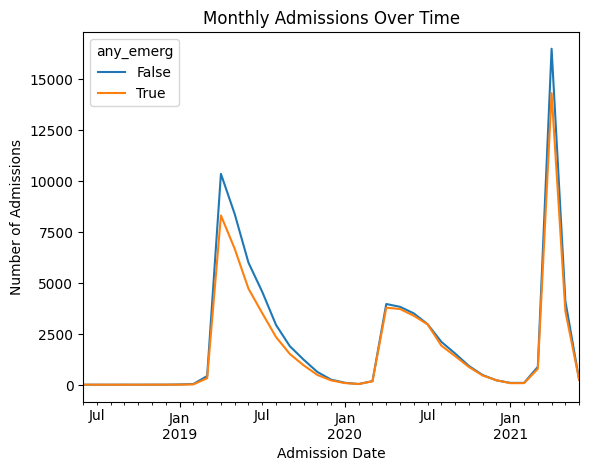

In [3]:
df["month"] = df["adm"].dt.to_period("M")
admissions_trend = df.groupby(["month", "any_emerg"])["spell_id"].count().unstack("any_emerg", fill_value=0)

admissions_trend.plot(title="Monthly Admissions Over Time")
plt.ylabel("Number of Admissions")
plt.xlabel("Admission Date")


In [4]:
admissions_trend

any_emerg,False,True
month,,
2018-06,0,1
2018-07,1,2
2018-08,0,1
2018-09,3,1
2018-10,1,2
2018-11,3,3
2018-12,3,4
2019-01,14,3
2019-02,34,18


Text(0.5, 1.0, 'Length of Stay Distribution')

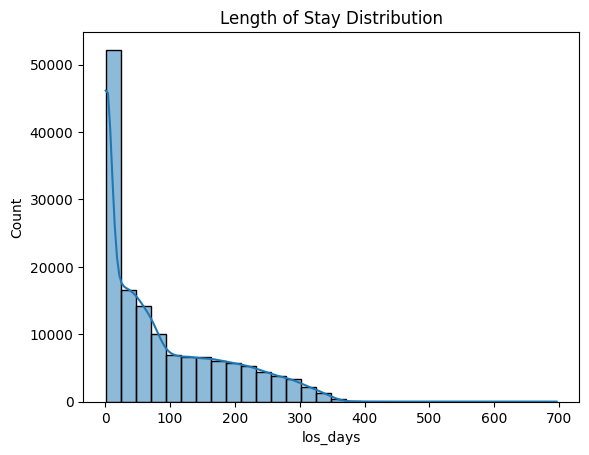

In [5]:
sns.histplot(df["los_days"].dropna(), bins=30, kde=True)
plt.title("Length of Stay Distribution")

Text(0.5, 1.0, 'LOS by Emergency Status')

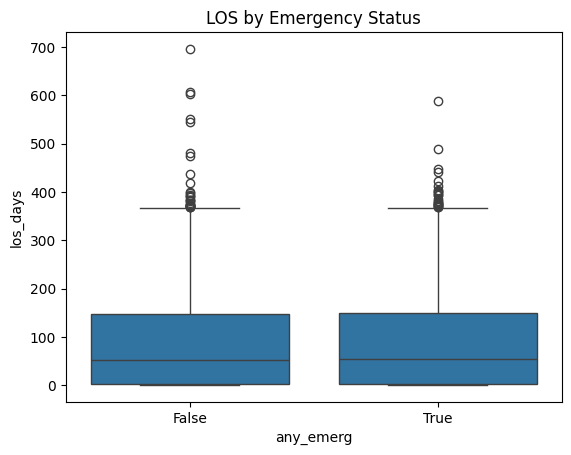

In [6]:
sns.boxplot(x="any_emerg", y="los_days", data=df)
plt.title("LOS by Emergency Status")

<Axes: xlabel='imd_quintile', ylabel='pct'>

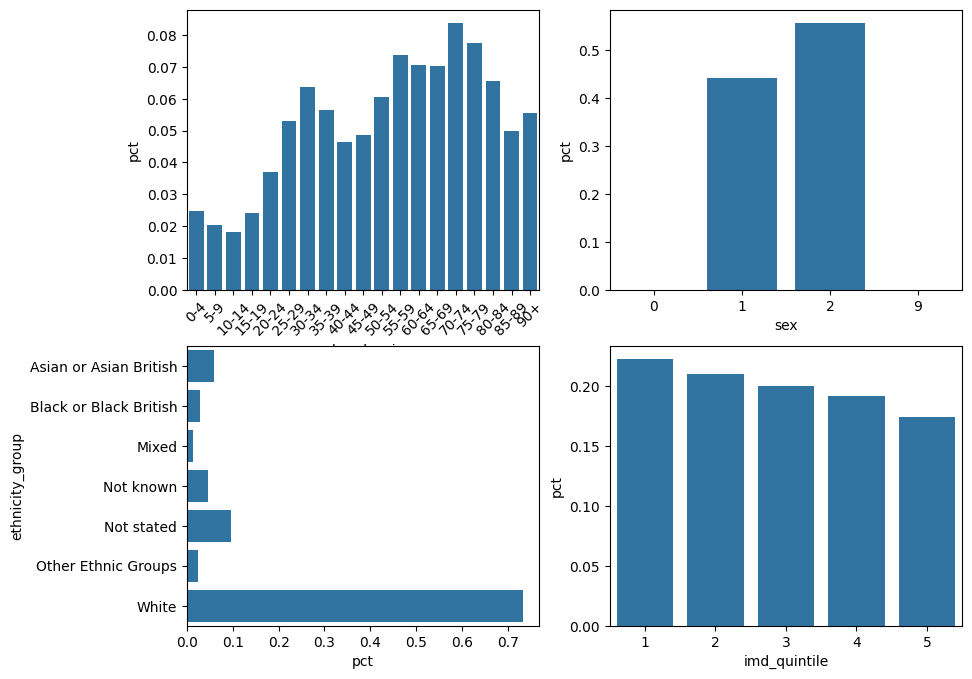

In [7]:
age_df = df["age_band_quinary"].value_counts(normalize=True).reset_index(name="pct")
sex_df = df["sex"].value_counts(normalize=True).reset_index(name="pct")
eth_df = df["ethnicity_group"].value_counts(normalize=True).reset_index(name="pct")
imd_df = df["imd_quintile"].value_counts(normalize=True).reset_index(name="pct")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.barplot(data=age_df, x="age_band_quinary", y="pct", ax=axes[0, 0])
axes[0, 0].tick_params(axis="x", rotation=45)
sns.barplot(data=sex_df, x="sex", y="pct", ax=axes[0, 1])
sns.barplot(data=eth_df, y="ethnicity_group", x="pct", ax=axes[1, 0])
sns.barplot(data=imd_df, x="imd_quintile", y="pct", ax=axes[1, 1])


Text(0.5, 1.0, 'Admissions by IMD Quintile')

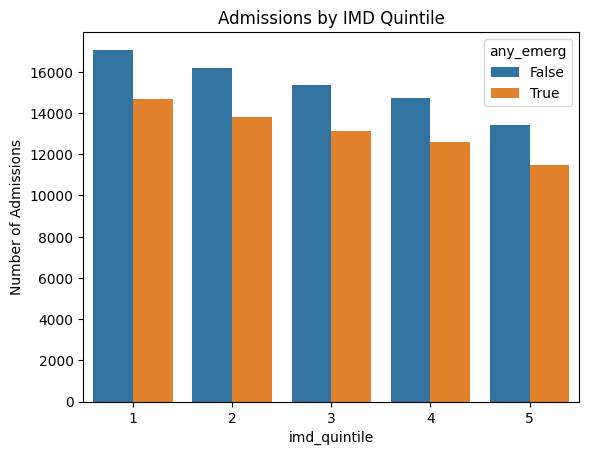

In [8]:
adm_by_imd = df.groupby(["imd_quintile", "any_emerg"])["spell_id"].count().reset_index()

sns.barplot(adm_by_imd, x="imd_quintile", y="spell_id", hue="any_emerg")
plt.ylabel("Number of Admissions")
plt.title("Admissions by IMD Quintile")


C:\Users\khize\AppData\Local\Temp\ipykernel_1936\815466078.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adm_by_eth = df.groupby(["ethnicity_group", "any_emerg"])["spell_id"].count().reset_index()


Text(0.5, 1.0, 'Admissions by Ethnic Group')

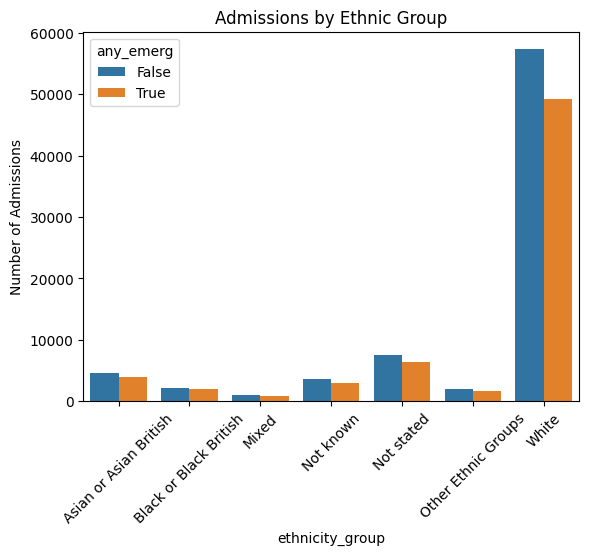

In [9]:
adm_by_eth = df.groupby(["ethnicity_group", "any_emerg"])["spell_id"].count().reset_index()

sns.barplot(adm_by_eth, x="ethnicity_group", y="spell_id", hue="any_emerg")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.title("Admissions by Ethnic Group")

Text(0.5, 1.0, 'Mean LOS by IMD Quintile')

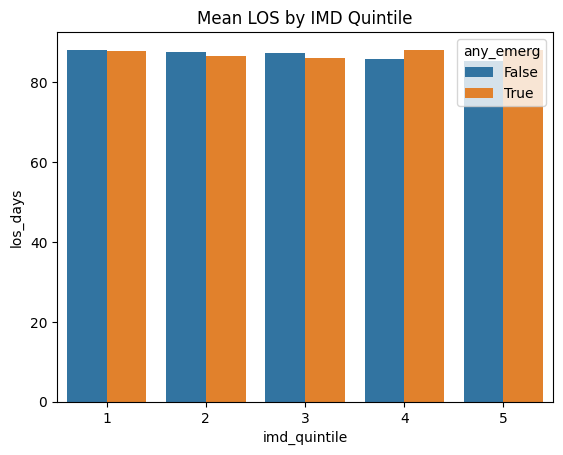

In [10]:
los_by_imd = df.groupby(["imd_quintile", "any_emerg"])["los_days"].mean().reset_index()

sns.barplot(los_by_imd, x="imd_quintile", y="los_days", hue="any_emerg")
plt.title("Mean LOS by IMD Quintile")

C:\Users\khize\AppData\Local\Temp\ipykernel_1936\3141733179.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  los_by_ethnicity = df.groupby(["ethnicity_group", "any_emerg"])["los_days"].mean().reset_index()


Text(0.5, 1.0, 'Mean LOS by Ethnicity Group')

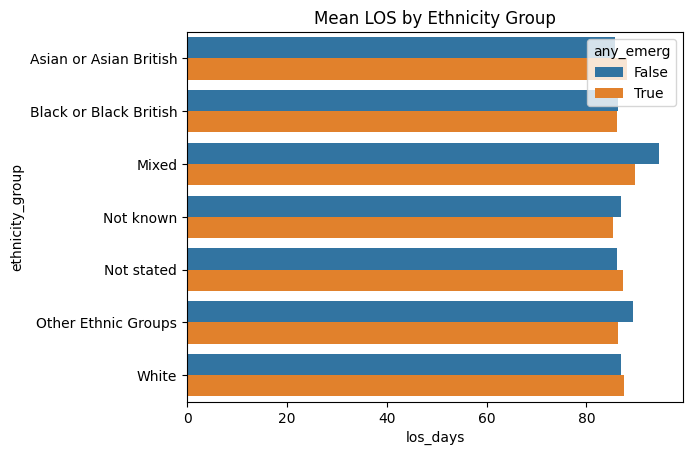

In [11]:
los_by_ethnicity = df.groupby(["ethnicity_group", "any_emerg"])["los_days"].mean().reset_index()

sns.barplot(los_by_ethnicity, y="ethnicity_group", x="los_days", hue="any_emerg")
plt.title("Mean LOS by Ethnicity Group")

Text(0.5, 1.0, 'Respiratory Conditions Distribution')

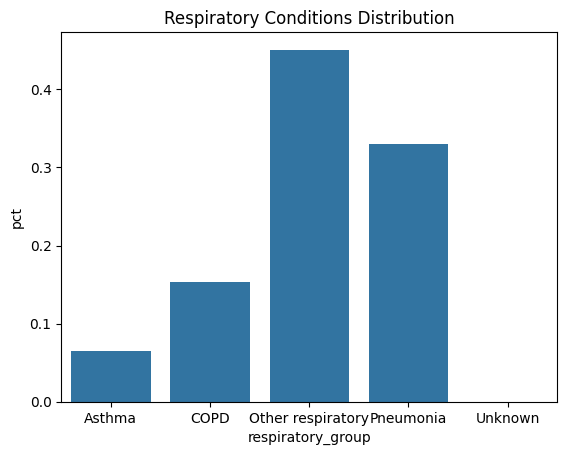

In [12]:
resp_group = df["respiratory_group"].value_counts(normalize=True).reset_index(name="pct")
sns.barplot(data=resp_group, x="respiratory_group", y="pct")
plt.title("Respiratory Conditions Distribution")


Text(0.5, 1.0, 'LOS by Respiratory Group')

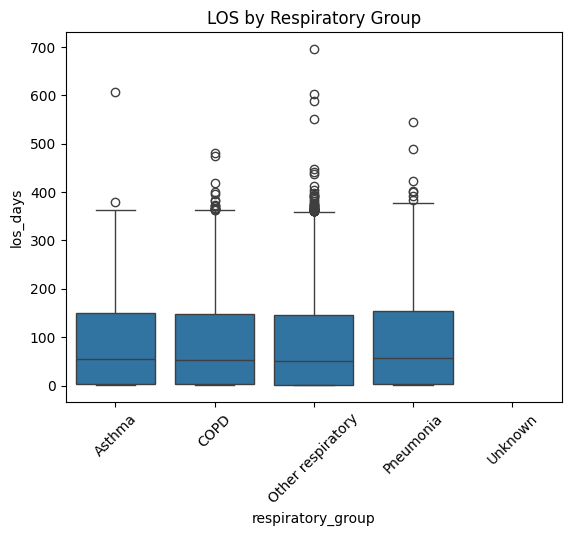

In [13]:
sns.boxplot(x="respiratory_group", y="los_days", data=df)
plt.xticks(rotation=45)
plt.title("LOS by Respiratory Group")

Text(0.5, 1.0, 'LOS by IMD Quintile')

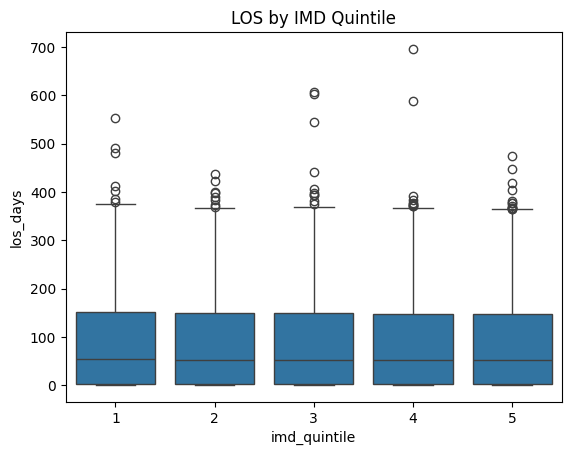

In [14]:
sns.boxplot(data=df, x="imd_quintile", y="los_days")
plt.title("LOS by IMD Quintile")

In [25]:
# === Applied Inferential Summary ===


results = []

# 1️⃣ LOS ~ respiratory_group  (Kruskal–Wallis)
groups = [g["los_days"].dropna() for _, g in df.groupby("respiratory_group") if g["los_days"].notna().any()]
stat, p = kruskal(*groups)
results.append({
    "Hypothesis": "LOS differs by respiratory group",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p-value": p
})

# 2️⃣ Age ~ respiratory_group  (Kruskal–Wallis)
groups = [g["age"].dropna() for _, g in df.groupby("respiratory_group") if g["age"].notna().any()]
stat, p = kruskal(*groups)
results.append({
    "Hypothesis": "Age differs by respiratory group",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p-value": p
})

# 3️⃣ Emergency × Diagnosis  (Chi-squared)
cont = pd.crosstab(df["respiratory_group"], df["any_emerg"])
chi2, p, dof, exp = chi2_contingency(cont)
results.append({
    "Hypothesis": "Emergency rate differs by diagnosis",
    "Test": "Chi-squared",
    "Statistic": chi2,
    "p-value": p
})

# 4️⃣ Admissions per patient ~ IMD quintile  (Kruskal–Wallis)
adm_per_patient = (
    df.groupby(["patient_id", "imd_quintile"])["spell_id"]
      .count()
      .reset_index(name="n_adm")
)
groups = [g["n_adm"] for _, g in adm_per_patient.groupby("imd_quintile")]
stat, p = kruskal(*groups)
results.append({
    "Hypothesis": "Admissions per patient differ by deprivation quintile",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p-value": p
})

# 5️⃣ Emergency × IMD quintile  (Chi-squared)
cont = pd.crosstab(df["imd_quintile"], df["any_emerg"])
chi2, p, dof, exp = chi2_contingency(cont)
results.append({
    "Hypothesis": "Emergency admission rate differs by deprivation quintile",
    "Test": "Chi-squared",
    "Statistic": chi2,
    "p-value": p
})

# Compile results
inferential_summary = pd.DataFrame(results)
display(inferential_summary)

# Optional: flag significant results
inferential_summary["Significant (<0.05)"] = inferential_summary["p-value"] < 0.05
print("\nSummary:")
print(inferential_summary.to_markdown(index=False))


C:\Users\khize\AppData\Local\Temp\ipykernel_1936\2445446248.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["los_days"].dropna() for _, g in df.groupby("respiratory_group") if g["los_days"].notna().any()]
C:\Users\khize\AppData\Local\Temp\ipykernel_1936\2445446248.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g["age"].dropna() for _, g in df.groupby("respiratory_group") if g["age"].notna().any()]


,Hypothesis,Test,Statistic,p-value
0,LOS differs by respiratory group,Kruskal–Wallis,43.618420,1.818822e-09
1,Age differs by respiratory group,Kruskal–Wallis,3.588871,3.094175e-01
2,Emergency rate differs by diagnosis,Chi-squared,3.469842,3.246946e-01
3,Admissions per patient differ by deprivation q...,Kruskal–Wallis,20.842613,3.402513e-04
4,Emergency admission rate differs by deprivatio...,Chi-squared,0.210446,9.948375e-01



Summary:
| Hypothesis                                               | Test           |   Statistic |     p-value | Significant (<0.05)   |
|:---------------------------------------------------------|:---------------|------------:|------------:|:----------------------|
| LOS differs by respiratory group                         | Kruskal–Wallis |   43.6184   | 1.81882e-09 | True                  |
| Age differs by respiratory group                         | Kruskal–Wallis |    3.58887  | 0.309417    | False                 |
| Emergency rate differs by diagnosis                      | Chi-squared    |    3.46984  | 0.324695    | False                 |
| Admissions per patient differ by deprivation quintile    | Kruskal–Wallis |   20.8426   | 0.000340251 | True                  |
| Emergency admission rate differs by deprivation quintile | Chi-squared    |    0.210446 | 0.994838    | False                 |


In [17]:
df["patient_id"].value_counts().describe()

count    128373.000000
mean          1.131897
std           0.538031
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          14.000000
Name: count, dtype: float64

C:\Users\khize\AppData\Local\Temp\ipykernel_1936\3896729386.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[value_col].values for _, g in gdf.groupby(group_col) if g[value_col].notna().any()]
C:\Users\khize\AppData\Local\Temp\ipykernel_1936\3896729386.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[value_col].values for _, g in gdf.groupby(group_col) if g[value_col].notna().any()]
C:\Users\khize\AppData\Local\Temp\ipykernel_1936\3896729386.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `

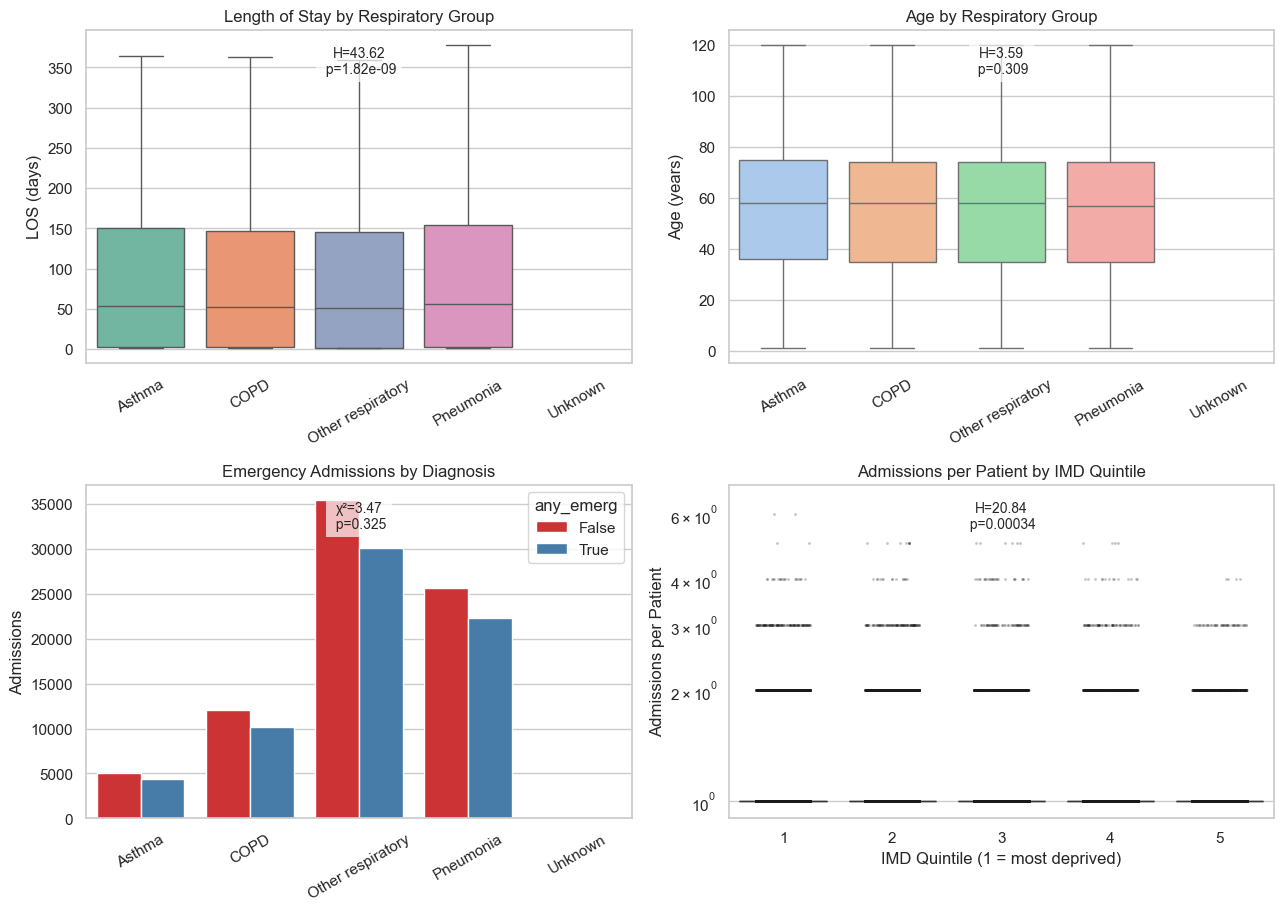

In [37]:
sns.set_theme(style="whitegrid")

# --- Helper: safe Kruskal across groups (drops NaNs, skips empty groups)
def kruskal_safe(df, group_col, value_col):
    gdf = df[[group_col, value_col]].dropna()
    groups = [g[value_col].values for _, g in gdf.groupby(group_col) if g[value_col].notna().any()]
    if len(groups) < 2:
        return float("nan"), float("nan")
    return kruskal(*groups)

# === p-values (with NA handling) ===
# 1) LOS ~ respiratory_group
H1, p1 = kruskal_safe(df, "respiratory_group", "los_days")

# 2) Age ~ respiratory_group
H2, p2 = kruskal_safe(df, "respiratory_group", "age")

# 3) Emergency × Diagnosis (drop NA levels)
ct1 = pd.crosstab(
    df["respiratory_group"].dropna(),
    df["any_emerg"].dropna()
)
X2_1, p3, *_ = chi2_contingency(ct1)

# 4) Admissions per patient ~ IMD (build per-patient, drop NAs)
adm_per_patient = (
    df[["patient_id", "imd_quintile", "spell_id"]]
      .dropna(subset=["patient_id", "imd_quintile"])            # drop NA ids/groups
      .groupby(["patient_id", "imd_quintile"])["spell_id"]
      .count()
      .reset_index(name="n_adm")
)
H4, p4 = kruskal_safe(adm_per_patient, "imd_quintile", "n_adm")

# 5) Emergency × IMD
ct2 = pd.crosstab(
    df["imd_quintile"].dropna(),
    df["any_emerg"].dropna()
)
X2_2, p5, *_ = chi2_contingency(ct2)

pvals = {
    "LOS_diag": (H1, p1),
    "Age_diag": (H2, p2),
    "Emerg_diag": (X2_1, p3),
    "Adm_imd": (H4, p4),
    "Emerg_imd": (X2_2, p5),
}

# --- Plot grid ---
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
axes = axes.flatten()

def annotate(ax, key, stat_label="H"):
    stat, p = pvals[key]
    lab = f"{stat_label}={stat:.2f}\n p={p:.3g}" if pd.notna(stat) else "insufficient data"
    ax.text(0.5, 0.95, lab, ha="center", va="top", transform=ax.transAxes,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"), fontsize=10)

# 1) LOS by Respiratory Group
sns.boxplot(
    data=df.dropna(subset=["respiratory_group", "los_days"]),
    x="respiratory_group", y="los_days",
    ax=axes[0], palette="Set2", showfliers=False
)
axes[0].set_title("Length of Stay by Respiratory Group")
axes[0].set_xlabel(""); axes[0].set_ylabel("LOS (days)")
axes[0].tick_params(axis='x', rotation=30)
annotate(axes[0], "LOS_diag", stat_label="H")

# 2) Age by Respiratory Group
sns.boxplot(
    data=df.dropna(subset=["respiratory_group", "age"]),
    x="respiratory_group", y="age",
    ax=axes[1], palette="pastel", showfliers=False
)
axes[1].set_title("Age by Respiratory Group")
axes[1].set_xlabel(""); axes[1].set_ylabel("Age (years)")
axes[1].tick_params(axis='x', rotation=30)
annotate(axes[1], "Age_diag", stat_label="H")

# 3) Emergency by Diagnosis (counts)
emerg_diag = (
    df.dropna(subset=["respiratory_group", "any_emerg"])
      .groupby(["respiratory_group", "any_emerg"])["spell_id"]
      .count().reset_index()
)
sns.barplot(
    data=emerg_diag, x="respiratory_group", y="spell_id", hue="any_emerg",
    ax=axes[2], palette="Set1"
)
axes[2].set_title("Emergency Admissions by Diagnosis")
axes[2].set_xlabel(""); axes[2].set_ylabel("Admissions")
axes[2].tick_params(axis='x', rotation=30)
annotate(axes[2], "Emerg_diag", stat_label="χ²")

# 4) Admissions per Patient by IMD (box + jitter, optional log scale)
ax = axes[3]
sns.boxplot(
    data=adm_per_patient, x="imd_quintile", y="n_adm",
    ax=ax, palette="Blues", showfliers=False
)
# jittered points to reveal the heavy mass at 1 + sparse repeats
sns.stripplot(
    data=adm_per_patient, x="imd_quintile", y="n_adm",
    ax=ax, color="k", size=2, alpha=0.25, jitter=0.25
)
# switch to log scale only if there are repeats
if (adm_per_patient["n_adm"] > 1).any():
    ax.set_yscale("log")
    ax.set_ylim(0.9, adm_per_patient["n_adm"].max() * 1.2)
ax.set_title("Admissions per Patient by IMD Quintile")
ax.set_xlabel("IMD Quintile (1 = most deprived)")
ax.set_ylabel("Admissions per Patient")
annotate(ax, "Adm_imd", stat_label="H")


# Remove empty 6th subplot
fig.delaxes(axes[4])
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()
